<a href="https://colab.research.google.com/github/DianaBarradasSanchez/EDPI/blob/main/Poisson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción a la Distribución de Poisson

Es una distribución de probabilidad discreta que se utiliza para modelar el número de veces que ocurre un evento aleatorio dentro de un intervalo continuo determinado.

Es una herramienta fundamental cuando conocemos la **tasa promedio de ocurrencia ($\lambda$)** de un evento, pero el momento exacto en el que sucede cada uno es completamente aleatorio e independiente del tiempo transcurrido desde el último evento.

## ¿En qué se utiliza principalmente?

En la práctica, la distribución de Poisson es el estándar para modelar situaciones de **líneas de espera (teoría de colas), control de calidad y gestión de operaciones**. Algunos de sus usos más comunes incluyen:
ngitud de dicho subintervalo.

>  La función de masa de probabilidad está dada por:
> $$P(X = x) = \frac{e^{-\lambda} \lambda^x}{x!}$$
> Donde una propiedad única y crucial de esta distribución es que su **media** y su **varianza** son exactamente iguales ($\mu = \sigma^2 = \lambda$).

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random as rm
import math


# 1. Mediante el método de la transformada inversa (OPTIMIZADO)


def poisson_inversa_recursiva(lam):

    #Generamos un valor aleatorio de Poisson usando el Método de la
    #Transformada Inversa

    u = rm.random()       # Generamos la variable Uniforme(0,1)
    k = 0                 # Contador de eventos (X)

    # P(X = 0) = e^(-λ) -> Condición inicial
    p = np.exp(-lam)
    F = p                 # Probabilidad acumulada inicial

    while u > F:
        k += 1
        # Relación recursiva: P(X = k) = P(X = k-1) * (λ / k)
        p = p * (lam / k)
        F += p            # Actualizamos la función de distribución acumulada

    return k

In [8]:
# Parámetros de la simulación
lambda_param = 5
num_muestras = 1000

# Generamos las muestras
muestras = [poisson_inversa_recursiva(lambda_param) for _ in range(num_muestras)]

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2466/749546303.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Histograma de muestras de Poisson ($\lambda = {lambda_param}$)')


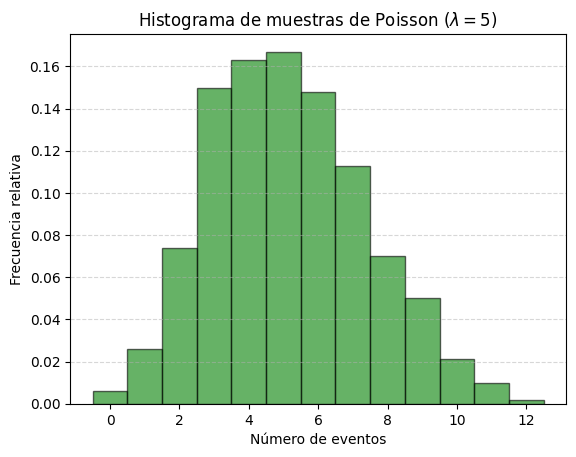

In [9]:
# Histograma
plt.hist(muestras, bins=np.arange(0, max(muestras) + 2) - 0.5,
         density=True, alpha=0.6, color='g', edgecolor='black')

# Configuración y etiquetas
plt.title(f'Histograma de muestras de Poisson ($\lambda = {lambda_param}$)')
plt.xlabel('Número de eventos')
plt.ylabel('Frecuencia relativa')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()